0.0
0.015789473684210527
0.031578947368421054
0.04736842105263158
0.06315789473684211
0.07894736842105263
0.09473684210526316
0.1105263157894737
0.12631578947368421
0.14210526315789473
0.15789473684210525
0.1736842105263158
0.18947368421052632
0.20526315789473684
0.2210526315789474
0.2368421052631579
0.25263157894736843
0.26842105263157895
0.28421052631578947
0.3
0.31
0.3463157894736842
0.38263157894736843
0.4189473684210526
0.4552631578947368
0.49157894736842106
0.5278947368421052
0.5642105263157895
0.6005263157894737
0.6368421052631579
0.6731578947368422
0.7094736842105263
0.7457894736842106
0.7821052631578947
0.8184210526315789
0.8547368421052632
0.8910526315789473
0.9273684210526316
0.9636842105263157
1.0


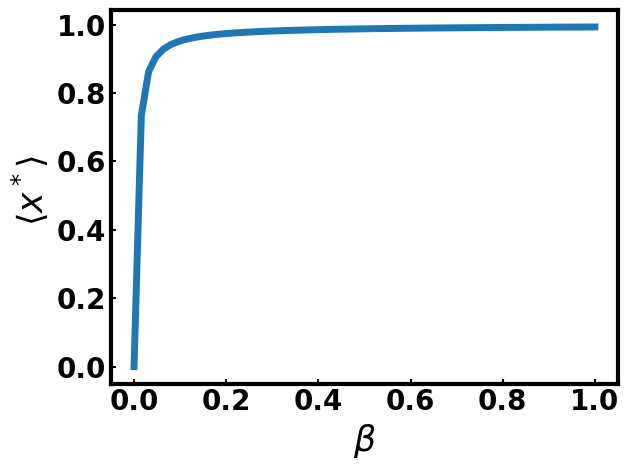

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""

AFTER TC , GCC ADJANCENY MATRIX 296

"""

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.io


beta_values = np.concatenate((np.linspace(0, 0.3, 20), np.linspace(0.31,1,20)))    
T_max = 10000  
t_eval = np.linspace(0, T_max, 10000)

theo_avg = []
theo_star = []
theo_star1 = []

network_data =np.loadtxt("A_after_GCC.csv", delimiter=",")
# network_data =np.loadtxt('C:/Users/Admin/Desktop/python/work_1/EFFECT OF POPULATION ABUNDANCES-PRE/er_p_0.02_n_500.txt',float)
#network_data = scipy.io.loadmat('/home/meera/dpcn/A_20_35.mat')

#mat_file = network_data['A']
G = nx.Graph(network_data)
A = nx.to_numpy_array(G)
A = np.array(A)

N = len(A)

degree=np.sum(A, axis=0)
avg=np.mean(degree)


def dxdt(t, x, beta, A):
    return -x + beta * (1 - x) * (A @ x)


x_star_values = []

for beta in beta_values:
    print(beta)
    
    x0 = np.random.rand(N)

    
    sol = solve_ivp(dxdt, [0, T_max], x0, args=(beta, A), t_eval=t_eval, rtol=1e-6, atol=1e-8)
    
    
    x_final = sol.y[:, -1]
    x_star = np.mean(x_final)
    x_star_values.append(x_star)
    
   
    
    
    

ax = plt.gca()  
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(3)


ax.tick_params(direction='in', colors='black', width=1.5)
ind1=(0,0.1,0.2,0.3,0.4,0.5)
ind=(0,0.2,0.4,0.6,0.8,1)
plt.xticks(fontsize=20,fontweight='bold')
plt.yticks(fontsize=20,fontweight='bold')





plt.plot(beta_values, x_star_values,lw=5)

plt.xlabel(r'$\beta$', fontsize=25,fontweight='bold')
plt.ylabel(r' $\langle x^*\rangle$', fontsize=25,fontweight='bold')

plt.tight_layout()
plt.show()

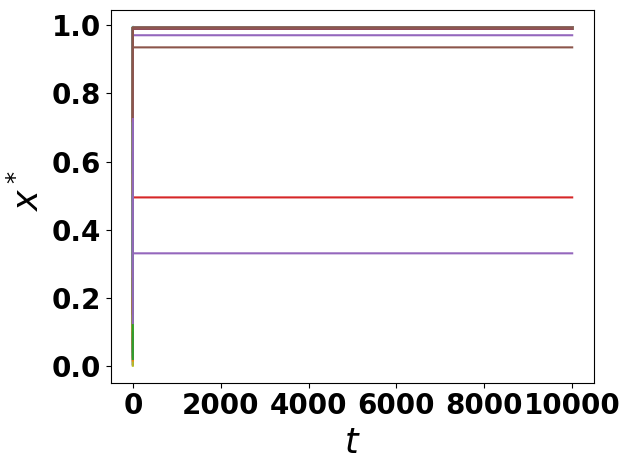

In [6]:
T_max = 10000  
t_eval = np.linspace(0, T_max, 10000)
beta = 0.5
theo_avg = []
theo_star = []
theo_star1 = []

#network_data = scipy.io.loadmat('C:/Users/Admin/Desktop/python/work_1/Tim_sug/A_20_35.mat')
#mat_file = network_data['A']
#G_ba = nx.barabasi_albert_graph(N, m)
#A = nx.to_numpy_array(G_ba)
#A = np.array(A)

#N = len(A)

degree=np.sum(A, axis=0)
avg=np.mean(degree)


def dxdt(t, x, beta, A):
    return -x + beta * (1 - x) * (A @ x)

x0 = np.random.rand(N)

sol = solve_ivp(dxdt, [0, T_max], x0, args=(beta, A), t_eval=t_eval, rtol=1e-6, atol=1e-8)
    


plt.xticks(fontsize=20,fontweight='bold')
plt.yticks(fontsize=20,fontweight='bold')


for i in range(N):
    plt.plot(t_eval, sol.y[i])

plt.xlabel(r'$t$', fontsize=25,fontweight='bold')
plt.ylabel(r' $ x^*$', fontsize=25,fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
N = len(A)
degree = np.sum(A, axis=0)
avg = np.mean(degree)
N = len(A)
degree = np.sum(A, axis=0)
avg = np.mean(degree)
print (N)
print (degree)
print(avg)

296
[258. 268. 259. 266. 269. 272. 276. 208. 269. 267. 190. 204. 190. 265.
 192. 209. 268. 262. 195. 194. 194. 262. 273. 260. 266. 256. 265. 268.
 252. 261. 271. 263. 203. 253. 261. 197. 268. 206. 197. 264. 193. 257.
 264. 256. 257. 269. 192. 253. 193. 270. 251. 275. 201. 260. 191. 263.
 262. 259. 263. 197. 200. 191. 272. 269.  67. 193. 194. 269. 261. 264.
 187. 197. 203. 267. 263. 205. 204. 266. 269. 267. 258. 199. 197. 260.
 190. 193. 262. 268. 266. 267. 207. 277. 191. 273. 259. 268. 262. 257.
 271. 265. 262. 267. 266. 265. 265. 188. 189. 266. 266. 193. 267. 263.
 206. 196. 186. 267. 267. 266. 269. 267. 259. 267. 262. 265. 259. 269.
 262. 258. 269. 191. 262. 194. 275. 202. 263. 271. 191. 266. 267. 241.
 262. 192. 264. 261. 197. 205. 268. 206. 261. 263. 265. 268. 261. 206.
 261. 266. 265. 257. 252. 267. 272. 265. 196. 190. 205. 265. 264. 260.
 264. 201. 275. 259. 262. 267.   1. 255. 209. 259. 273. 268. 268. 266.
 265. 195. 271. 193. 200. 263. 261. 265. 268. 262. 262. 272. 209. 261.
 2

In [7]:
np.save("after_xtime.npy", sol.y.mean(axis=0))
np.save("after_xstar.npy", x_star_values)